
========== DATASET ==========

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

========== CONFUSION MATRIX ==========

[[16  0  0]
 [ 0 18  0]
 [ 0  0 11]]

========== VALUES ==========
TP: 16
FP: 0
TN: 29
FN: 0

========== PERFORMANCE ==========
Accuracy     : 1.0
Error Rate   : 0.0
Precision    : 1.0
Recall       : 1.0

========== CLASSIFICATION REPORT ==========

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        16
Iris-versicolor       1.00      1.00      1.00        18
 Iris-virginica       1.00      1.00      1

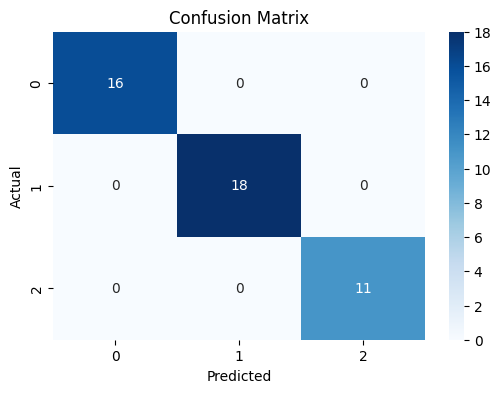


========== SAMPLE PREDICTIONS ==========

            Actual        Predicted
0   Iris-virginica   Iris-virginica
1  Iris-versicolor  Iris-versicolor
2      Iris-setosa      Iris-setosa
3   Iris-virginica   Iris-virginica
4      Iris-setosa      Iris-setosa
5   Iris-virginica   Iris-virginica
6      Iris-setosa      Iris-setosa
7  Iris-versicolor  Iris-versicolor
8  Iris-versicolor  Iris-versicolor
9  Iris-versicolor  Iris-versicolor


In [2]:
# =========================================================
# DATA ANALYTICS III - NAÏVE BAYES (IRIS DATASET)
# COMPLETE PRACTICAL CODE
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# =========================================================
# 1. LOAD DATASET
# =========================================================

df = pd.read_csv("iris.csv")   # File should be in same folder

print("\n========== DATASET ==========\n")
print(df.head())

# =========================================================
# 2. FEATURES AND TARGET
# =========================================================

X = df.iloc[:, :-1]   # Features
y = df.iloc[:, -1]    # Target (species)

# =========================================================
# 3. TRAIN-TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# =========================================================
# 4. APPLY NAÏVE BAYES
# =========================================================

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# =========================================================
# 5. CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_test, y_pred)

print("\n========== CONFUSION MATRIX ==========\n")
print(cm)

# =========================================================
# 6. TP, FP, TN, FN (Binary: Setosa vs Others)
# =========================================================

y_test_bin = (y_test == 'Iris-setosa').astype(int)
y_pred_bin = (y_pred == 'Iris-setosa').astype(int)

cm_bin = confusion_matrix(y_test_bin, y_pred_bin)

TN, FP, FN, TP = cm_bin.ravel()

print("\n========== VALUES ==========")
print("TP:", TP)
print("FP:", FP)
print("TN:", TN)
print("FN:", FN)

# =========================================================
# 7. PERFORMANCE METRICS
# =========================================================

accuracy = (TP + TN) / (TP + TN + FP + FN)
error_rate = 1 - accuracy
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print("\n========== PERFORMANCE ==========")
print("Accuracy     :", accuracy)
print("Error Rate   :", error_rate)
print("Precision    :", precision)
print("Recall       :", recall)

# =========================================================
# 8. CLASSIFICATION REPORT
# =========================================================

print("\n========== CLASSIFICATION REPORT ==========\n")
print(classification_report(y_test, y_pred))

# =========================================================
# 9. ACCURACY (SKLEARN)
# =========================================================

print("\nAccuracy (sklearn):", accuracy_score(y_test, y_pred))

# =========================================================
# 10. CONFUSION MATRIX HEATMAP
# =========================================================

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================================================
# 11. ACTUAL vs PREDICTED VALUES
# =========================================================

result = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
print("\n========== SAMPLE PREDICTIONS ==========\n")
print(result.head(10))